<a href="https://colab.research.google.com/github/gencere757/ARDA-GENCER-DSA210-TERM-PROJECT/blob/main/DSA210_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Filtering, Cleaning And Transforming The Data
## 1.1 Importing the necessary libraries


In [4]:
import pandas as pd
import numpy as np

## 1.2 Obesity Rate Data
  Here, the obesity rate data were made into a dataframe, the empty or NaN values were cleared, and a seperate column for log values were added since they will be needed to apply log transform when plotting later.

In [5]:
foodDF = pd.read_csv('StateAndCountyData.csv')
obesityDF = foodDF[foodDF['Variable_Code'] == "PCT_OBESE_ADULTS22"]
obesityDF = obesityDF.dropna()
obesityDF = obesityDF[obesityDF['Value']>0].copy()
obesityDF

,FIPS,State,County,Variable_Code,Value
374301,1001.0,AL,Autauga,PCT_OBESE_ADULTS22,38.3
374312,1003.0,AL,Baldwin,PCT_OBESE_ADULTS22,38.3
374323,1005.0,AL,Barbour,PCT_OBESE_ADULTS22,38.3
374334,1007.0,AL,Bibb,PCT_OBESE_ADULTS22,38.3
374345,1009.0,AL,Blount,PCT_OBESE_ADULTS22,38.3
...,...,...,...,...,...
408830,56037.0,WY,Sweetwater,PCT_OBESE_ADULTS22,34.3
408841,56039.0,WY,Teton,PCT_OBESE_ADULTS22,34.3
408852,56041.0,WY,Uinta,PCT_OBESE_ADULTS22,34.3
408863,56043.0,WY,Washakie,PCT_OBESE_ADULTS22,34.3


## 1.3 The Walkability Index Data
Here, the walkability index data was extracted from its .csv file.

In [6]:
walkDF = pd.read_csv('WalkabilityIndexByCounty.csv')
walkDF

,Unnamed: 0,GEOID10,NatWalkInd,County
0,1,1001,5.234375,Autauga
1,2,1003,6.450355,Baldwin
2,3,1005,5.188406,Barbour
3,4,1007,5.033333,Bibb
4,5,1009,4.666667,Blount
...,...,...,...,...
1897,3607,72139,4.865079,Trujillo Alto
1898,3609,72143,4.015152,Vega Alta
1899,3611,72145,4.450450,Vega Baja
1900,3614,72149,3.254902,Villalba


## 1.4 Fast Food Restaurants Per 1000 People
The data was extracted from the .csv file, the empty rows were cleaned and log transformation was applied to data since the distribution here was mostly right-skewed.

In [7]:
restaurantDF = foodDF[foodDF['Variable_Code'] == "FFRPTH20"]   #Fast food restaurants per 1000 people in county
restaurantDF = restaurantDF[restaurantDF['Value']>0].copy()
restaurantDF['Log_Transformed_Restaurants'] = np.log1p(restaurantDF['Value'])
restaurantDF

,FIPS,State,County,Variable_Code,Value,Log_Transformed_Restaurants
728093,1001.0,AL,Autauga,FFRPTH20,0.801496,0.588618
728105,1003.0,AL,Baldwin,FFRPTH20,0.750152,0.559702
728117,1005.0,AL,Barbour,FFRPTH20,0.976046,0.681098
728129,1007.0,AL,Bibb,FFRPTH20,0.316227,0.274769
728141,1009.0,AL,Blount,FFRPTH20,0.414658,0.346888
...,...,...,...,...,...,...
765725,56031.0,WY,Platte,FFRPTH20,0.466309,0.382748
765737,56033.0,WY,Sheridan,FFRPTH20,0.680426,0.519048
765761,56037.0,WY,Sweetwater,FFRPTH20,0.609285,0.475790
765773,56039.0,WY,Teton,FFRPTH20,0.680938,0.519352


## 1.5 Combining  The Data Into A Single Data Frame

In [8]:
walkSubset = walkDF[['GEOID10', 'NatWalkInd']].copy()
walkSubset = walkSubset.rename(columns={
    'GEOID10': 'FIPS',
    'NatWalkInd': 'Walkability_Index'
})

restSubset = restaurantDF[['FIPS', 'Value', 'Log_Transformed_Restaurants']].copy()
restSubset = restSubset.rename(columns={
    'Value': 'Fast_Food_Per_1000',
    'Log_Transformed_Restaurants': 'Log_Fast_Food'
})

obeseSubset = obesityDF[['FIPS', 'Value']].copy()
obeseSubset = obeseSubset.rename(columns={
    'Value': 'Obesity_Rate'
})

combinedDF = walkSubset.merge(obeseSubset, on='FIPS', how='inner') \
                       .merge(restSubset, on='FIPS', how='inner')
combinedDF = combinedDF.dropna()
combinedDF.to_csv('Processed Data.csv', index=False)
combinedDF

,FIPS,Walkability_Index,Obesity_Rate,Fast_Food_Per_1000,Log_Fast_Food
0,1001,5.234375,38.3,0.801496,0.588618
1,1003,6.450355,38.3,0.750152,0.559702
2,1005,5.188406,38.3,0.976046,0.681098
3,1007,5.033333,38.3,0.316227,0.274769
4,1009,4.666667,38.3,0.414658,0.346888
...,...,...,...,...,...
1672,56005,7.333333,34.3,0.642729,0.496359
1673,56013,6.763441,34.3,0.559554,0.444400
1674,56021,7.887255,34.3,0.626274,0.486291
1675,56025,8.940972,34.3,0.631071,0.489237


# 2. Data Visualizations

## 2.1 Graphs, Correlation, Preliminary Analysis

### 2.1.1 Importing The Necessary Libraries

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

### 2.1.1 Getting The General Statistical Information About The Data

In [10]:
combinedDF.describe()

,FIPS,Walkability_Index,Obesity_Rate,Fast_Food_Per_1000,Log_Fast_Food
count,1677.000000,1677.000000,1677.000000,1677.000000,1677.000000
mean,28599.777579,7.137120,34.838462,0.694503,0.516197
std,16036.389020,2.342961,3.549965,0.291989,0.143567
min,1001.000000,1.000000,24.300000,0.165298,0.152977
25%,16069.000000,5.607843,33.200000,0.537661,0.430262
50%,28033.000000,6.462867,35.200000,0.678763,0.518057
75%,42039.000000,7.903846,37.700000,0.807698,0.592054
max,56033.000000,15.957258,41.000000,6.684492,2.039204


### 2.1.2 Plotting The Walkability Index Data As A Histogram

To be able to have a general idea as to how the data are distributed, histogram plots were drawn for each of them.

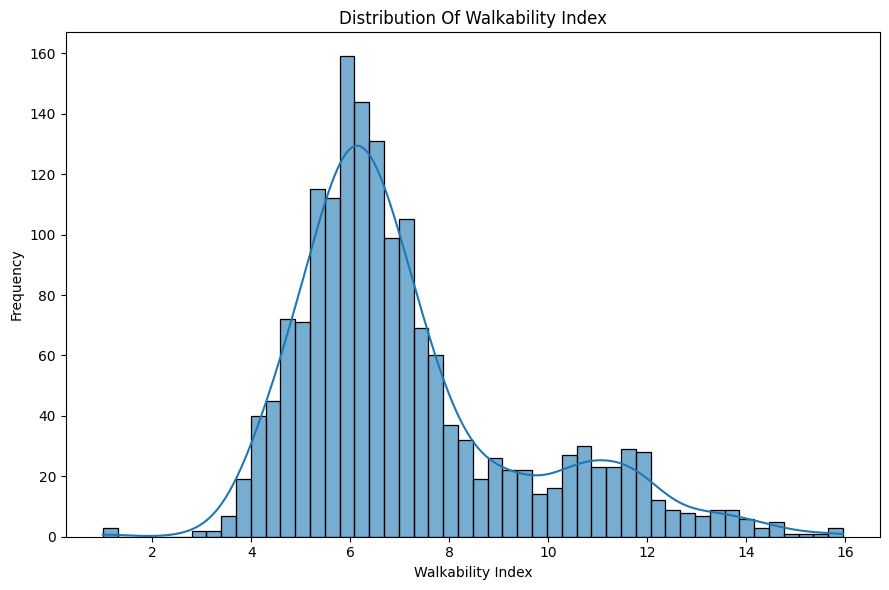

In [11]:
plt.figure(figsize=(9,6))
sns.histplot(combinedDF['Walkability_Index'],bins=50,kde=True,alpha=0.6)
plt.title("Distribution Of Walkability Index")
plt.xlabel("Walkability Index")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### 2.1.3 Plotting The Fast Food Restaurant Data As A Histogram

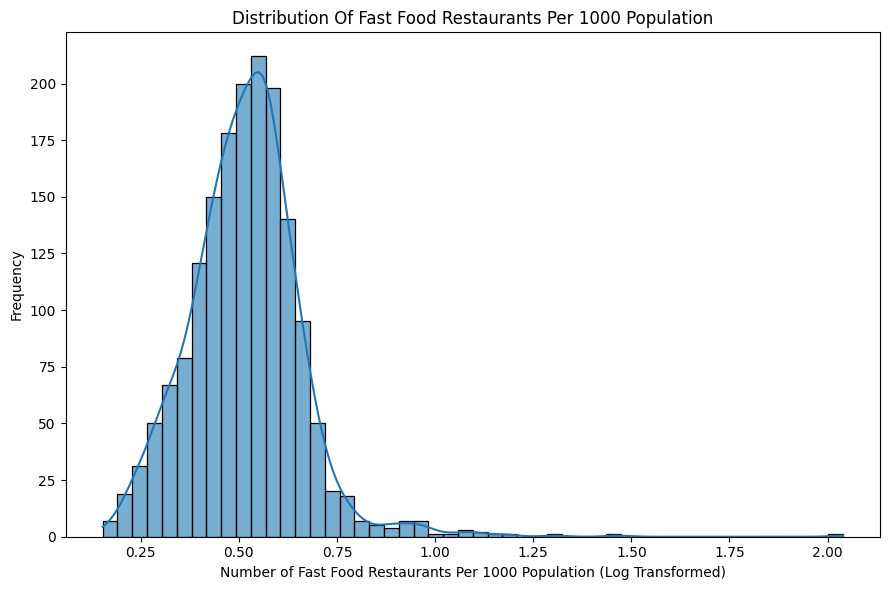

In [12]:
plt.figure(figsize=(9,6))
sns.histplot(combinedDF['Log_Fast_Food'],bins=50,kde=True,alpha=0.6)
plt.title("Distribution Of Fast Food Restaurants Per 1000 Population")
plt.xlabel("Number of Fast Food Restaurants Per 1000 Population (Log Transformed)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### 2.1.2 Plotting The Obesity Rate Data As A Histogram



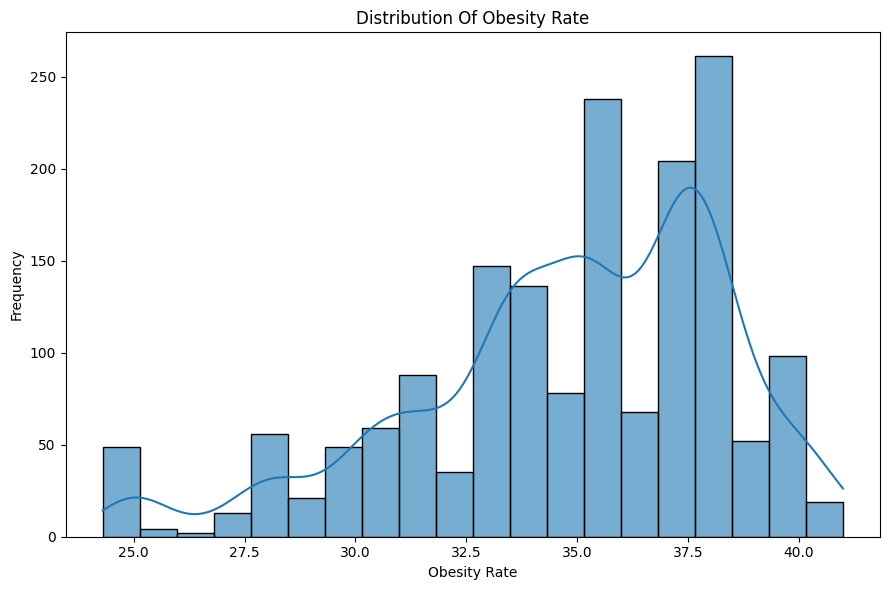

In [13]:
plt.figure(figsize=(9,6))
sns.histplot(combinedDF['Obesity_Rate'],bins=20,kde=True,alpha=0.6)
plt.title("Distribution Of Obesity Rate")
plt.xlabel("Obesity Rate")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### 2.1.3 Mapping The Walkability Index And Fast Food Data Against Obesity Rates As A Scatterplot

The scatterplots were used as to see if there is any correlation that can be seen by the eye between the features and the obesity rate.

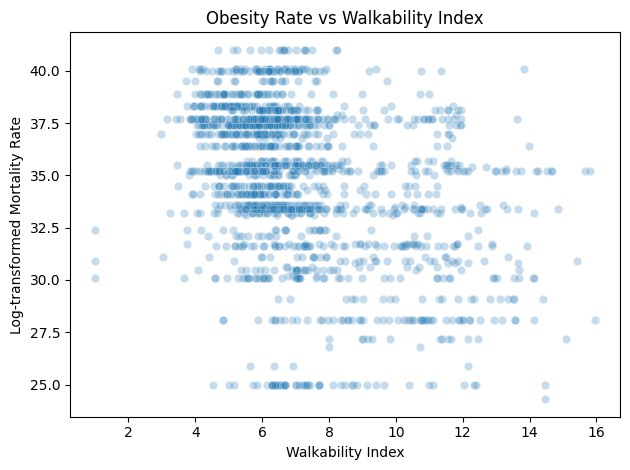

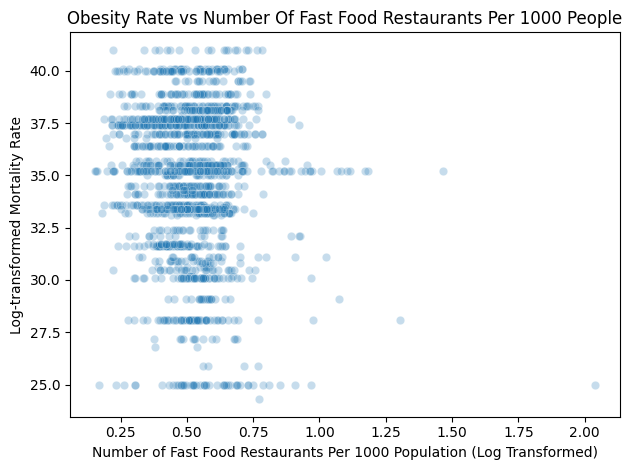

In [14]:
sns.scatterplot(x=combinedDF['Walkability_Index'], y=combinedDF['Obesity_Rate'],alpha=0.25)
plt.title('Obesity Rate vs Walkability Index')
plt.xlabel('Walkability Index')
plt.ylabel('Log-transformed Mortality Rate')
plt.tight_layout()
plt.show()

sns.scatterplot(x=combinedDF['Log_Fast_Food'], y=combinedDF['Obesity_Rate'],alpha=0.25)
plt.title('Obesity Rate vs Number Of Fast Food Restaurants Per 1000 People')
plt.xlabel('Number of Fast Food Restaurants Per 1000 Population (Log Transformed)')
plt.ylabel('Log-transformed Mortality Rate')
plt.tight_layout()
plt.show()

### 2.1.4 Creating A Correlation Matrix To Compare Each Data Against One Another

Text(0.5, 1.0, 'Correlation Matrix')

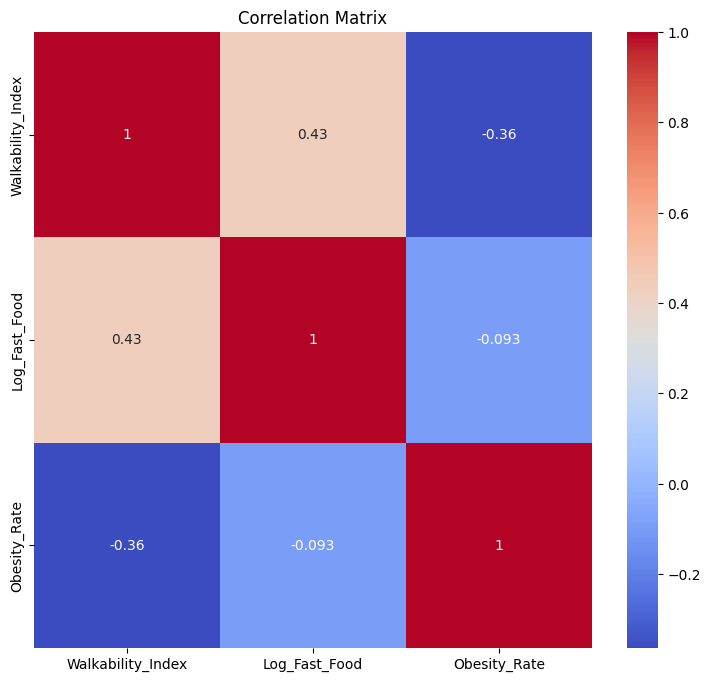

In [15]:
plt.figure(figsize=(9, 8))
sns.heatmap(combinedDF[['Walkability_Index', 'Log_Fast_Food', 'Obesity_Rate']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')

As can be seen, we see almost no correlation between fast food restaurant count and obesity rate. However, between walkabilty index and obesity rate, a quite large negative correlation can be observed.

## 2.2 Mapping The Data

Since the data that will be used dependds on locations (i.e counties in US), the data were plotted on a map for better visualization.

### 2.2.1 Importing The Necessary Libraries To Map The Data

In [16]:
import plotly.express as px
import plotly.graph_objects as go

### 2.2.2 Mapping The Obesity Rate Data On The US Map

In [17]:
combinedDF['FIPS'] = combinedDF['FIPS'].astype(str).str.zfill(5)

fig = px.choropleth(
    combinedDF,
    geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
    locations='FIPS',
    color='Obesity_Rate',
    color_continuous_scale="Reds",
    scope="usa",
    hover_name='FIPS',
    hover_data={
        'FIPS': False,
        'Obesity_Rate': ':.1f',
        'Walkability_Index': ':.2f',
        'Fast_Food_Per_1000': ':.3f'
    },
    labels={'Obesity_Rate': 'Obesity_Rate'},
    title='US County-Level Data Visualization For Obesity Rates'
)

fig.update_layout(
    geo=dict(
        lakecolor='rgb(255, 255, 255)',
    ),
    margin={"r": 0, "t": 50, "l": 0, "b": 0},
    height=600
)

fig.show()

### 2.2.3 Mapping The Walkability Index Data On The US Map

In [18]:
combinedDF['FIPS'] = combinedDF['FIPS'].astype(str).str.zfill(5)

fig = px.choropleth(
    combinedDF,
    geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
    locations='FIPS',
    color='Walkability_Index',
    color_continuous_scale="Reds",
    scope="usa",
    hover_name='FIPS',
    hover_data={
        'FIPS': False,
        'Obesity_Rate': ':.1f',
        'Walkability_Index': ':.2f',
        'Fast_Food_Per_1000': ':.3f'
    },
    labels={'Walkability_Index': 'Walkability_Index'},
    title='US County-Level Data Visualization For Walkability Index'
)

fig.update_layout(
    geo=dict(
        lakecolor='rgb(255, 255, 255)',
    ),
    margin={"r": 0, "t": 50, "l": 0, "b": 0},
    height=600
)

fig.show()

### 2.2.4 Mapping The Fast Food Restaurant Data On The US Map

In [19]:
combinedDF['FIPS'] = combinedDF['FIPS'].astype(str).str.zfill(5)

fig = px.choropleth(
    combinedDF,
    geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
    locations='FIPS',
    color='Log_Fast_Food',
    color_continuous_scale="Reds",
    scope="usa",
    hover_name='FIPS',
    hover_data={
        'FIPS': False,
        'Obesity_Rate': ':.1f',
        'Walkability_Index': ':.2f',
        'Fast_Food_Per_1000': ':.3f'
    },
    labels={'Log_Fast_Food': 'Log_Fast_Food'},
    title='US County-Level Data Visualization For Fast Food Restaurant Per 1000 Population'
)

fig.update_layout(
    geo=dict(
        lakecolor='rgb(255, 255, 255)',
    ),
    margin={"r": 0, "t": 50, "l": 0, "b": 0},
    height=600
)

fig.show()

# 3. Hypothesis Testing



## 3.1 Defining Hypotheses And Testing Methods

Our Hypotheses are as follows:

1.   Walkability Index

Hₒ : The walkability index and obesity rate is not negatively correlated.

Hₐ : The walkability index and obesity rate is negatively correlated. As walkability index gets higher, obesity rates get lower.

2.   Fast Food Data

Hₒ : The fast food restaurant count per 1000 people and obesity rate is not positively correlated.

Hₐ : The fast food restaurant count per 1000 people and obesity rate is positively correlated.




---


Here, permutation testing was used to calculate different distributions assuming that the null hypotheses were true. After that, the correlation coefficients for these were saved and the real correlation coefficient (here, spearman correlation was used as obesity data didn't seem normally distributed and pearson correlation is a parametric test) was compared against this distribution of correlation coefficients to determine if there was any correlation.

In [20]:
from scipy import stats

## 3.2 Permutation Test Function

In [21]:
def permutation_test_correlation(x, y, n_permutations=10000, alternative='two-sided'):
    x = np.asarray(x)
    y = np.asarray(y)

    observed_corr = stats.spearmanr(x, y).correlation

    perm_corrs = np.array([
        stats.spearmanr(x, np.random.permutation(y)).correlation
        for _ in range(n_permutations)
    ])

    if alternative == 'two-sided':
        extreme = np.sum(np.abs(perm_corrs) >= np.abs(observed_corr))
    elif alternative == 'less':      # H1: observed_corr is smaller (more negative)
        extreme = np.sum(perm_corrs <= observed_corr)
    elif alternative == 'greater':   # H1: observed_corr is larger (more positive)
        extreme = np.sum(perm_corrs >= observed_corr)
    else:
        raise ValueError("alternative must be 'two-sided', 'less', or 'greater'")

    # Monte Carlo p-value correction
    p_value = (extreme + 1) / (n_permutations + 1)
    return observed_corr, p_value, perm_corrs

In [22]:
#Walkabilty
obs_corr_walkability, p_val_walkability, perm_dist_walkability = permutation_test_correlation(
    combinedDF['Walkability_Index'],
    combinedDF['Obesity_Rate'],
    n_permutations=10000,
    alternative='less'  # H1: negative correlation
)
print(f"Walkability Index\n")
print(f"Observed correlation: {obs_corr_walkability:.4f}")
print(f"P-value (one-sided, H1: r < 0): {p_val_walkability:.4f}")
print(f"Interpretation: {'Significant' if p_val_walkability < 0.05 else 'Not significant'} at α=0.05")
if p_val_walkability < 0.05:
  print(f"The walkability index is negatively correlated with obesity rate."),
else:
  print(f"The walkability index is not negatively correlated with obesity rate.")
print('\n')

#Fast Food Data
obs_corr_food, p_val_food, perm_dist_food = permutation_test_correlation(
    combinedDF['Log_Fast_Food'],
    combinedDF['Obesity_Rate'],
    n_permutations=10000,
    alternative='greater'  # H1: positive correlation
)
print(f"Fast Food Data\n")
print(f"Observed correlation: {obs_corr_food:.4f}")
print(f"P-value (one-sided, H1: r < 0): {p_val_food:.4f}")
print(f"Interpretation: {'Significant' if p_val_food < 0.05 else 'Not significant'} at α=0.05")
if p_val_food < 0.05:
  print(f"The fast food restaurant count per 1000 people is positively correlated with the obesity rate.")
else:
  print(f"The fast food restaurant count per 1000 people is not positively correlated with the obesity rate.")

Walkability Index

Observed correlation: -0.3581
P-value (one-sided, H1: r < 0): 0.0001
Interpretation: Significant at α=0.05
The walkability index is negatively correlated with obesity rate.


Fast Food Data

Observed correlation: -0.0329
P-value (one-sided, H1: r < 0): 0.9112
Interpretation: Not significant at α=0.05
The fast food restaurant count per 1000 people is not positively correlated with the obesity rate.


## 3.2 Plotting The Distributions And Observed Correlations

Here, to visualize  it better, the randomly generated distributions and the observed correlation is plotted in the same graph.

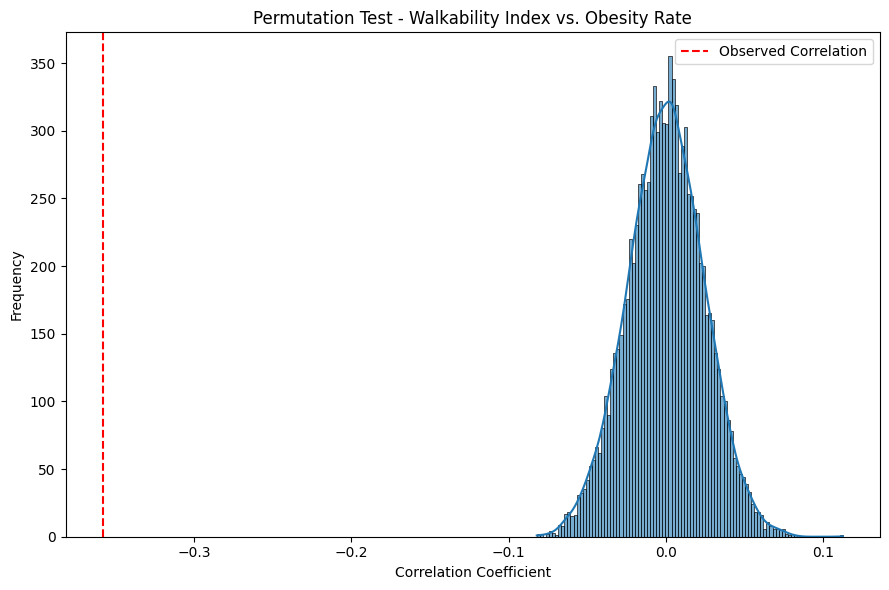

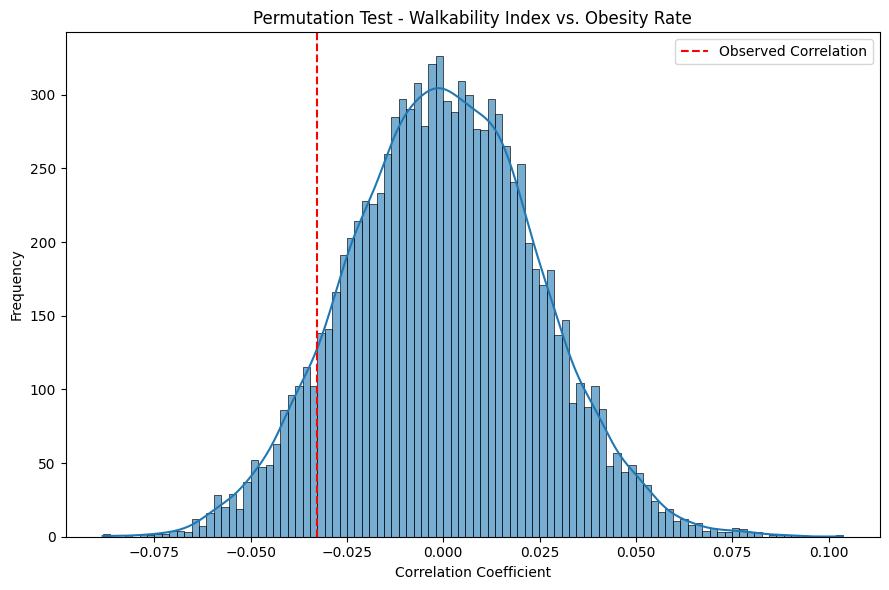

In [23]:
plt.figure(figsize=(9,6))
sns.histplot(perm_dist_walkability,bins=100,kde=True,alpha=0.6)
plt.title("Permutation Test - Walkability Index vs. Obesity Rate")
plt.axvline(x=obs_corr_walkability, color='red', linestyle='--', label = 'Observed Correlation')
plt.xlabel("Correlation Coefficient")
plt.ylabel("Frequency")
plt.tight_layout()
plt.legend()
plt.show()

plt.figure(figsize=(9,6))
sns.histplot(perm_dist_food,bins=100,kde=True,alpha=0.6)
plt.title("Permutation Test - Walkability Index vs. Obesity Rate")
plt.axvline(x=obs_corr_food, color='red', linestyle='--', label = 'Observed Correlation')
plt.xlabel("Correlation Coefficient")
plt.ylabel("Frequency")
plt.tight_layout()
plt.legend()
plt.show()

# 4. Machine Learning


In [24]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
combinedDF

,FIPS,Walkability_Index,Obesity_Rate,Fast_Food_Per_1000,Log_Fast_Food
0,01001,5.234375,38.3,0.801496,0.588618
1,01003,6.450355,38.3,0.750152,0.559702
2,01005,5.188406,38.3,0.976046,0.681098
3,01007,5.033333,38.3,0.316227,0.274769
4,01009,4.666667,38.3,0.414658,0.346888
...,...,...,...,...,...
1672,56005,7.333333,34.3,0.642729,0.496359
1673,56013,6.763441,34.3,0.559554,0.444400
1674,56021,7.887255,34.3,0.626274,0.486291
1675,56025,8.940972,34.3,0.631071,0.489237


In [25]:
predictors = ["Walkability_Index","Log_Fast_Food"]
outcome = "Obesity_Rate"

In [26]:
VIF_calc_X = combinedDF[predictors]
VIF_calc_X = sm.add_constant(VIF_calc_X)

VIF_data = pd.DataFrame()
VIF_data["feature"] = VIF_calc_X.columns
VIF_data["VIF"] = [variance_inflation_factor(VIF_calc_X.values,i) for i in range(VIF_calc_X.shape[1])]

VIF_data

,feature,VIF
0,const,16.696543
1,Walkability_Index,1.227023
2,Log_Fast_Food,1.227023


In [27]:
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

In [28]:
X = combinedDF[predictors].values
y = combinedDF[outcome].values

# Defining Models and Hyperparameter Grids
models = {
    "LinearRegression": (
        Pipeline([
            ('scaler', StandardScaler()),
            ('model', LinearRegression())
        ]),
        {}
    ),
    "KNN": (
        Pipeline([
            ('scaler', StandardScaler()),
            ('model', KNeighborsRegressor())
        ]),
        {
            'model__n_neighbors': list(range(1,21))
        }
    ),
    "DecisionTree": (
        Pipeline([
            ('scaler', StandardScaler()),
            ('model', DecisionTreeRegressor())
        ]),
        {
            'model__max_depth': [3, 5, 10, 20, 30, None],
            'model__min_samples_leaf' : [2, 5, 10]
        }
    ),
    "RandomForest": (
        Pipeline([
            ('scaler', StandardScaler()),
            ('model', RandomForestRegressor())
        ]),
        {
            'model__n_estimators': [5, 10, 50],
            'model__max_depth': [5, 10, None]
        }
    )
}

outer_cv = KFold(n_splits=10, shuffle=True, random_state=42)
results = {}

In [29]:
for name, (pipe, param_grid) in models.items():
    y_preds = np.zeros_like(y)
    best_params = []

    for train_idx, test_idx in outer_cv.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Inner CV with grid search
        inner_cv = KFold(n_splits=10, shuffle=True, random_state=1)
        grid = GridSearchCV(pipe, param_grid, cv=inner_cv, scoring='r2', n_jobs=-1)
        grid.fit(X_train, y_train)
        best_params.append(grid.best_params_)

        # Predict on outer test fold
        y_preds[test_idx] = grid.predict(X_test)

    results[name] = {"predictions": y_preds, "best_params": best_params}
    print(f"{name} R²: {r2_score(y, y_preds):.3f}, RMSE: {np.sqrt(np.mean((y - y_preds)**2)):.3f}")



LinearRegression R²: 0.132, RMSE: 3.307
KNN R²: 0.149, RMSE: 3.275
DecisionTree R²: 0.140, RMSE: 3.292
RandomForest R²: 0.173, RMSE: 3.227


In [30]:
print("\nBest hyperparameters per model (one per outer fold):")
for name, result in results.items():
  print(f"\n{name}:")
  for i, params in enumerate(result['best_params']):
      print(f"  Fold {i + 1}: {params}")


Best hyperparameters per model (one per outer fold):

LinearRegression:
  Fold 1: {}
  Fold 2: {}
  Fold 3: {}
  Fold 4: {}
  Fold 5: {}
  Fold 6: {}
  Fold 7: {}
  Fold 8: {}
  Fold 9: {}
  Fold 10: {}

KNN:
  Fold 1: {'model__n_neighbors': 20}
  Fold 2: {'model__n_neighbors': 20}
  Fold 3: {'model__n_neighbors': 19}
  Fold 4: {'model__n_neighbors': 19}
  Fold 5: {'model__n_neighbors': 18}
  Fold 6: {'model__n_neighbors': 20}
  Fold 7: {'model__n_neighbors': 20}
  Fold 8: {'model__n_neighbors': 19}
  Fold 9: {'model__n_neighbors': 16}
  Fold 10: {'model__n_neighbors': 17}

DecisionTree:
  Fold 1: {'model__max_depth': 3, 'model__min_samples_leaf': 10}
  Fold 2: {'model__max_depth': 3, 'model__min_samples_leaf': 5}
  Fold 3: {'model__max_depth': 3, 'model__min_samples_leaf': 2}
  Fold 4: {'model__max_depth': 3, 'model__min_samples_leaf': 10}
  Fold 5: {'model__max_depth': 3, 'model__min_samples_leaf': 10}
  Fold 6: {'model__max_depth': 5, 'model__min_samples_leaf': 10}
  Fold 7: {'mode

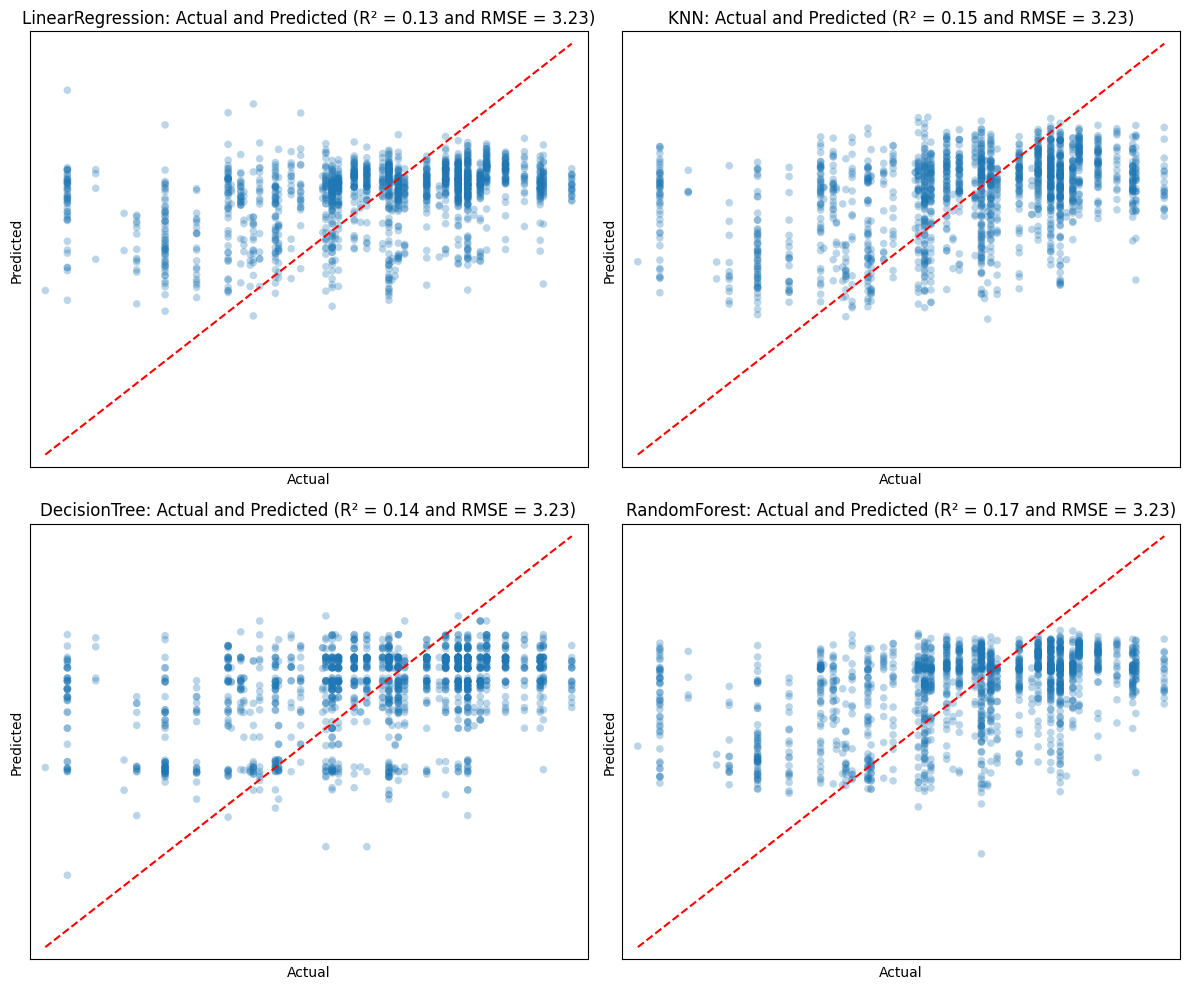

<Figure size 640x480 with 0 Axes>

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, result) in enumerate(results.items()):
  ax = axes[i]
  y_pred = result["predictions"]
  ax.grid(True)
  ax.set_xticks(np.arange(4.6, 6.2, 0.2))
  ax.set_yticks(np.arange(4.6, 6.2, 0.2))
  min_val = min(y.min(), y_pred.min())
  max_val = max(y.max(), y_pred.max())
  ax.plot([min_val, max_val], [min_val, max_val], 'r--', label="Ideal Fit")
  ax.scatter(y, y_pred, alpha=0.3, edgecolor="none", s=30, label=name)
  ax.plot([4.6,6.2], [4.6,6.2], 'r--', label = "Ideal Fit")  # y = x line
  ax.set_title(f"{name}: Actual and Predicted (R² = {r2_score(y, y_pred):.2f} and RMSE = {np.sqrt(np.mean((y - y_preds)**2)):.2f})")
  ax.set_xlabel("Actual")
  ax.set_ylabel("Predicted")
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
  padding = 0.5
  min_val = min(y.min(), y_pred.min()) - padding
  max_val = max(y.max(), y_pred.max()) + padding
  ax.set_xlim(min_val, max_val)
  ax.set_ylim(min_val, max_val)

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()